In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions


# import os
# os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # 临时解决方案
# os.environ['OMP_NUM_THREADS'] = '1'  # 限制线程数 

# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='hist')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('%.1f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Таблица анализа данных, коэффициент корреляции')
    plt.show()

In [2]:
path = "/Users/teng/PycharmProjects/ML/2025lab1/dataset_2_ECG/модуль 2 - датасет - практика.csv"
raw_table_data = pd.read_csv(path,nrows=5000)
raw_table_data.head(5)

,subject_id,Count_subj,study_id,cart_id,Healthy_Status,eeg_time,eeg_date,report_0,report_1,report_2,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,19557662,27,40000017,6848296,0,8:44 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79
1,18477137,93,40000029,6848296,0,9:54 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70
2,16598616,3,40000035,6376932,1,9:07 AM,28.06.2015,Sinus tachycardia,NaN,Normal ECG except for rate,...,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77
3,16368287,7,40000079,6214760,1,5:14 PM,15.07.2015,Sinus rhythm,NaN,Normal ECG,...,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69
4,18370366,2,40000084,6632385,0,1:52 PM,27.09.2015,Sinus rhythm,NaN,NaN,...,<not specified>,659,368,29999,504,590,868,84,80,77


In [3]:
# 从csv文件中导入数据
# path = "/Users/teng/PycharmProjects/ML/2025lab1/dataset_2_ECG/модуль 2 - датасет - практика.csv"
columns_to_filter = ['rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']
full_df_filtered = raw_table_data[(raw_table_data[columns_to_filter] < 2000).all(axis=1)]
full_df_filtered = full_df_filtered[(full_df_filtered['p_onset'] < full_df_filtered['p_end']) & (full_df_filtered['qrs_onset'] < full_df_filtered['qrs_end'])]

full_df_filtered = full_df_filtered[[col for col in full_df_filtered.columns if col != 'Healthy_Status'] + ['Healthy_Status']]



In [4]:
table_data = full_df_filtered[['rr_interval','p_end','qrs_onset','qrs_end','t_end','p_axis','qrs_axis','t_axis','Healthy_Status']].copy()
table_data.head()

,rr_interval,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,659,128,170,258,518,81,77,79,0
1,722,124,162,246,504,77,75,70,0
2,600,130,162,244,474,79,72,77,1
3,659,146,180,254,538,79,66,69,1
6,952,146,198,282,598,24,80,20,1


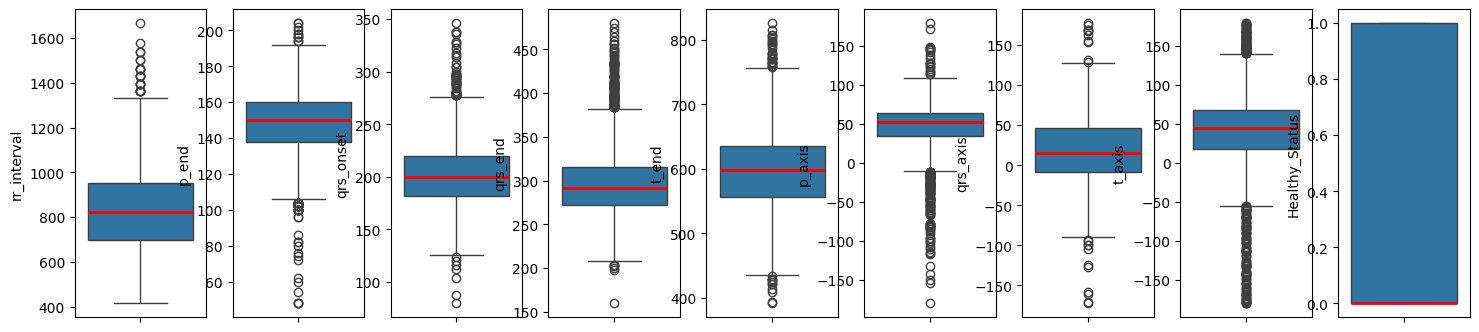

In [6]:
# 分析数据分布
n = table_data.shape[1]
fig,ax = plt.subplots(1,n, figsize=(n*2,4), sharex=True)
for i in range(n):
    plt.sca(ax[i])
    col = table_data.columns[i]
    sns.boxplot(y = table_data.iloc[:,i],data=table_data, medianprops={"color": "r", "linewidth": 2})

In [5]:
# удаляем аномалии из данных (убрать все значения более 5000)
# 去除离群值
for i, v in enumerate(table_data):
  table_data = table_data.drop(table_data[table_data.iloc[:,i] > 10000].index)

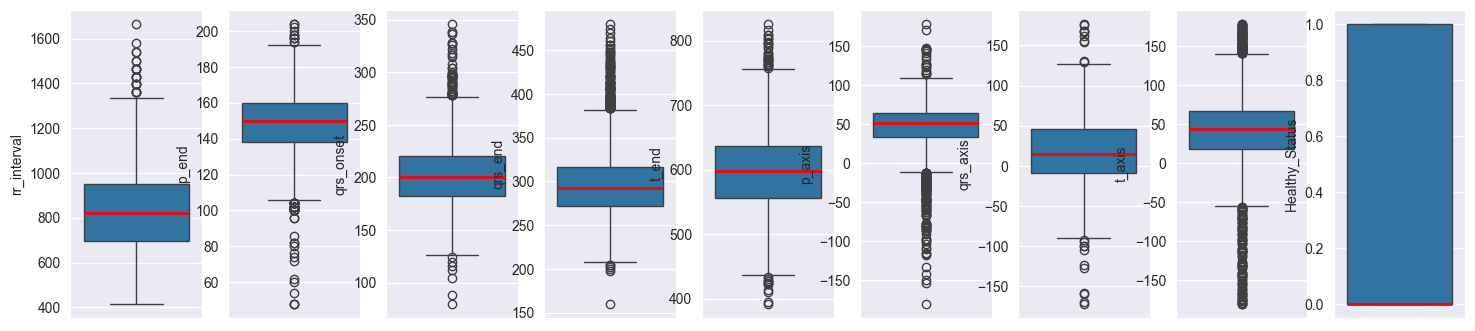

In [8]:
n = table_data.shape[1]
fig,ax = plt.subplots(1,n, figsize=(n*2,4), sharex=True)
for i in range(n):
    plt.sca(ax[i])
    col = table_data.columns[i]
    sns.boxplot(y = table_data.iloc[:,i],data=table_data,
                medianprops={"color": "r", "linewidth": 2})
    plt.tight_layout

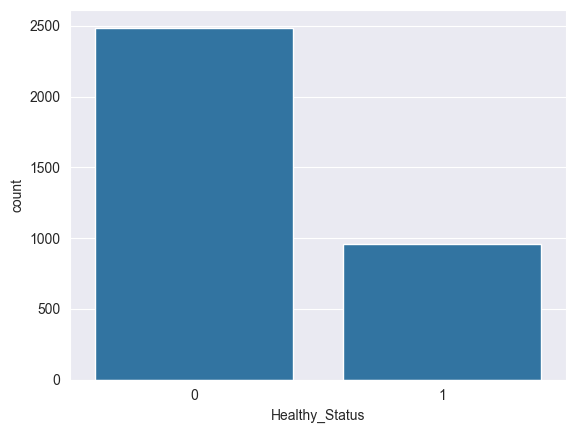

In [9]:
# 分析健康情况正负样本数量关系
sns.countplot(data=table_data, x="Healthy_Status")
plt.title
("Distribution of Healthy Status")
plt.show()

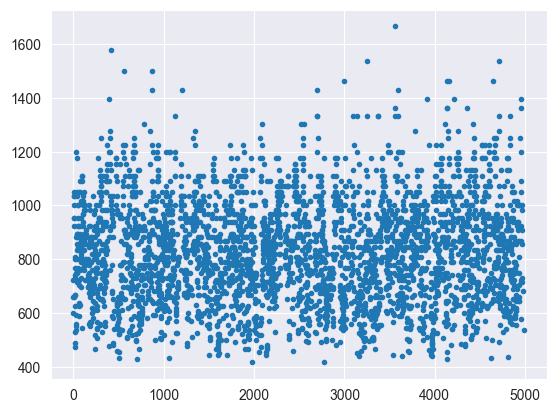

In [11]:
#example view
plt.plot(table_data['rr_interval'],'.')
plt.show()

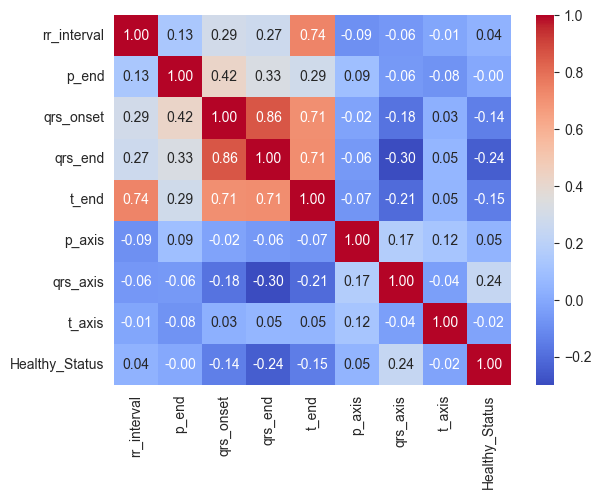

In [10]:
sns.heatmap(table_data.corr(),annot=True,fmt="0.2f",cmap="coolwarm")
plt.show()

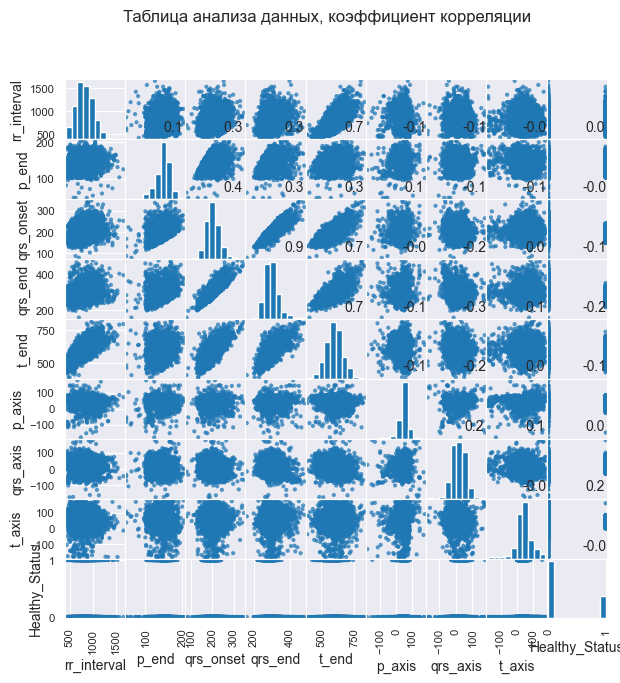

In [12]:
plotScatterMatrix(table_data, 7, 10)

In [ ]:
fig,ax = plt.subplots(figsize=(15,5))
# sns.lineplot(x='age',y='debtinc',data=data,ax=ax)
sns.lineplot(x='rr_interval',y='p_axis',data=table_data,ax=ax)

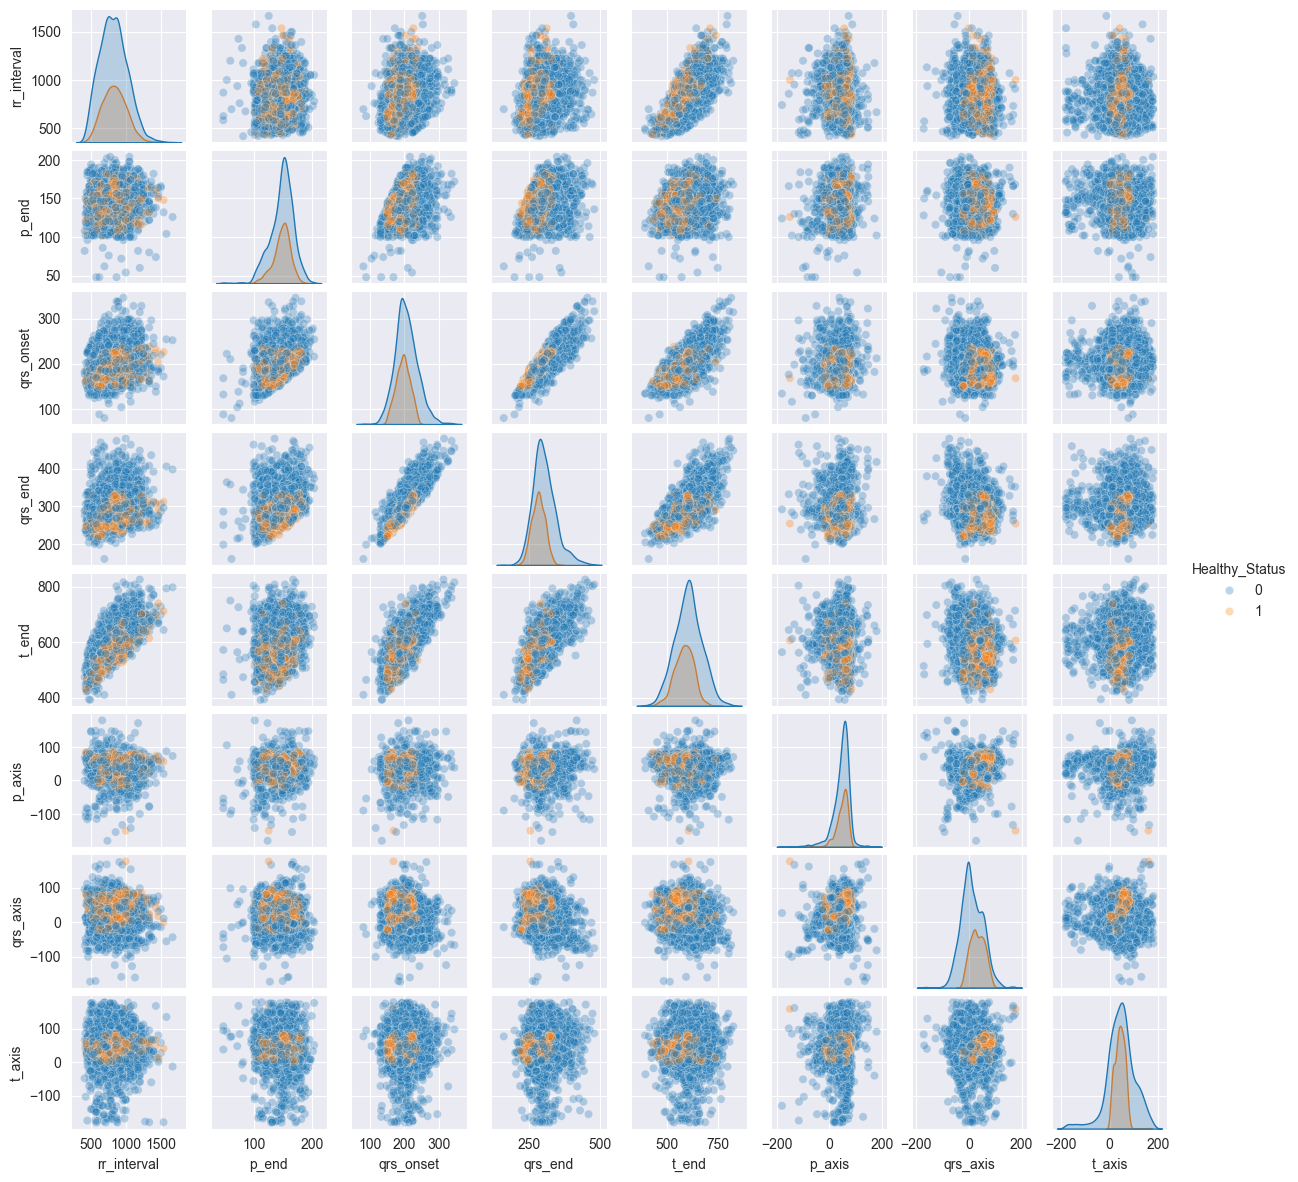

In [13]:
labels = pd.DataFrame(table_data['Healthy_Status'])
# 观察将康情况在不同数据列中的分布
sns.pairplot(table_data, hue = "Healthy_Status",
             height=1.5,
             plot_kws=dict(alpha=0.3))



<Axes: xlabel='rr_interval', ylabel='qrs_end'>

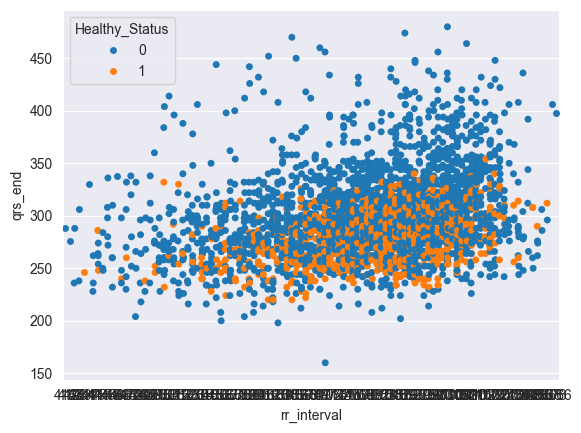

In [14]:
sns.stripplot(x=table_data['rr_interval'],y=table_data['qrs_end'],
              hue=table_data['Healthy_Status'],jitter=True)

<Axes: xlabel='rr_interval'>

/Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 58.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


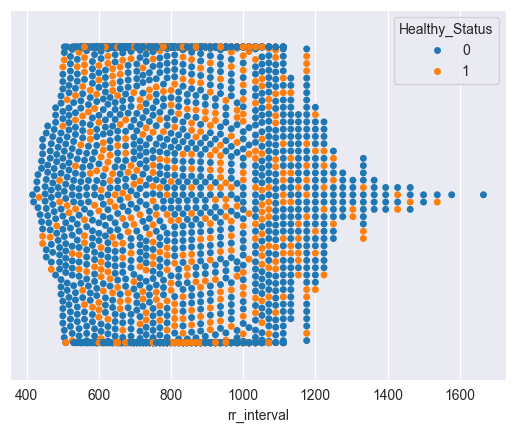

In [15]:
sns.swarmplot(data=table_data, x="rr_interval", hue="Healthy_Status")

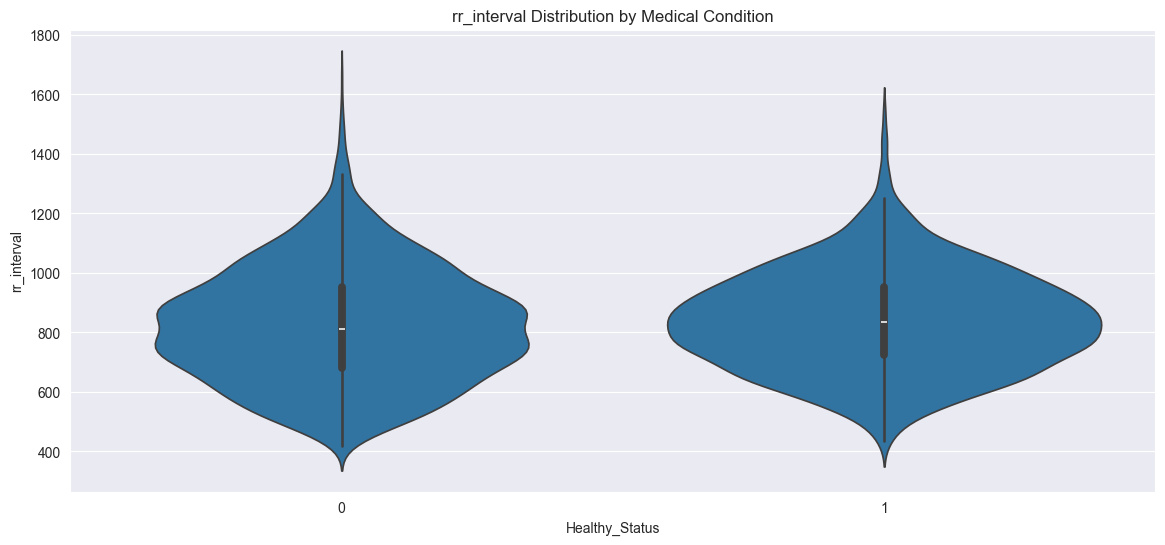

In [16]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=table_data, y='rr_interval', x='Healthy_Status')
plt.title('rr_interval Distribution by Medical Condition')
plt.show()

In [9]:
# Обработка данных: PCA, ICA, t-SNE
# PCA - principal component analysis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#data_pca = data
data_pca = table_data
data_pca = data_pca.drop('Healthy_Status', axis = 1)
data_pca.columns

Index(['rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis',
       'qrs_axis', 't_axis'],
      dtype='object')

In [18]:
#cancer = load_breast_cancer()
# Before applying PCA, each feature should be centered (zero mean) and with unit variance
scaled_data = StandardScaler().fit(data_pca).transform(data_pca)
pca = PCA(n_components = 2).fit(scaled_data)
# PCA(copy=True, n_components=2, whiten=False)
x_pca = pca.transform(scaled_data)
print(table_data.shape, x_pca.shape)

(3448, 9) (3448, 2)


In [19]:
percent = pca.explained_variance_ratio_
print(percent)
print(sum(percent))
#To see how much variance is preserved for each dataset.

[0.38683481 0.14936521]
0.5362000202274945


In [20]:
def pca_explained(X, threshold):
  features = X.shape[1]
  for i in range(2, features):
    pca = PCA(n_components = i).fit(X)
    sum_ = pca.explained_variance_ratio_
    # add all components explained variances
    percent = sum(sum_)
    print('{} components at {:.2f}% explained variance'.format(i,percent*100))
    if percent > threshold:
      break

pca_explained(scaled_data, 0.85)

2 components at 53.62% explained variance
3 components at 66.96% explained variance
4 components at 79.92% explained variance
5 components at 88.94% explained variance


Text(0, 0.5, 'Second Principal Component')

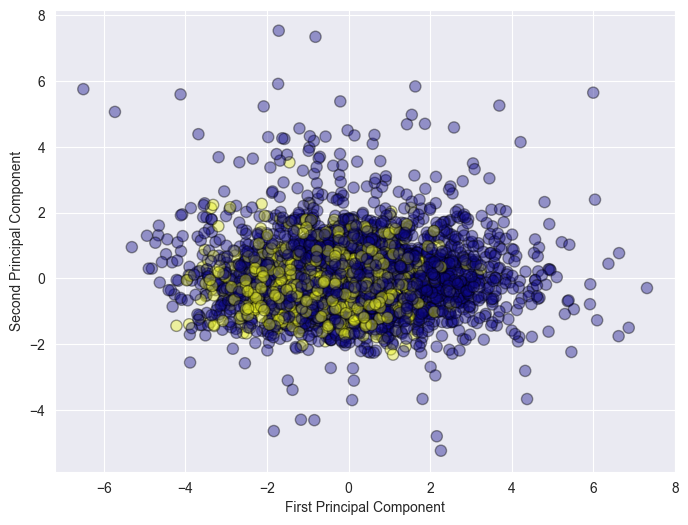

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0], x_pca[:,1], c=table_data['Healthy_Status'], cmap='plasma', alpha=0.4, edgecolors='black', s=65);
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')


/var/folders/fq/0nv7cscd17g4437j7sttxzf40000gn/T/ipykernel_50929/3474971604.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.arrow(0, 0, components['PCA1'][a], -components['PCA2'][a], alpha=0.5, facecolor='white', head_width=.01)
/var/folders/fq/0nv7cscd17g4437j7sttxzf40000gn/T/ipykernel_50929/3474971604.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.annotate(i, (components['PCA1'][a]*offset, -components['PCA2'][a]*offset), color='orange')


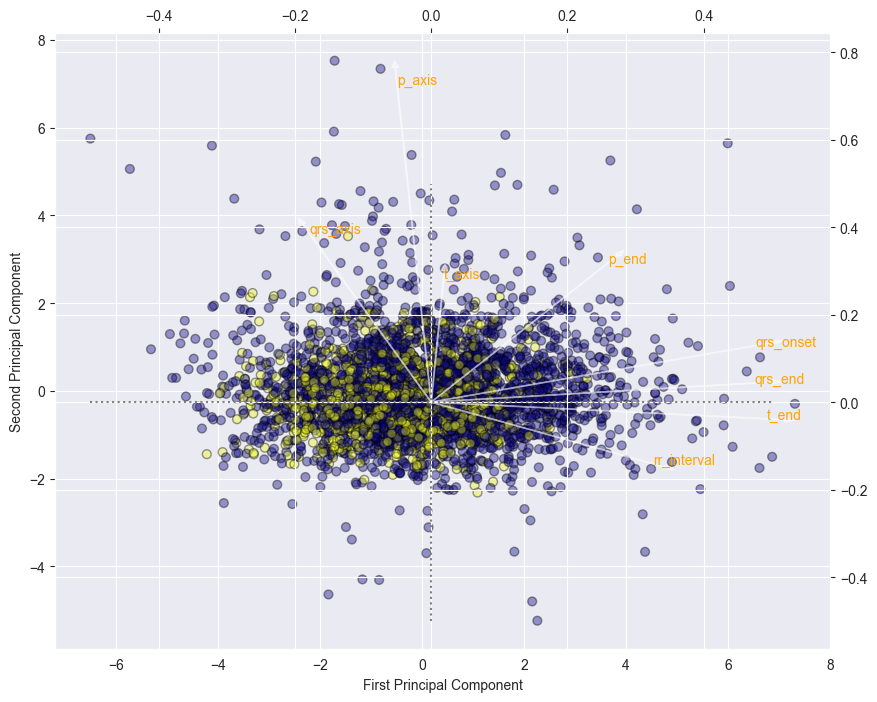

In [22]:
# put feature values into dataframe
components = pd.DataFrame(pca.components_.T, index=data_pca.columns, columns= ['PCA1','PCA2'])
# plot size
plt.figure(figsize=(10,8))
# main scatterplot
plt.scatter(x_pca[:,0], x_pca[:,1], c=table_data['Healthy_Status'],
            cmap='plasma', alpha=0.4, edgecolors='black', s=40);
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
#plt.ylim(15,-15);
#plt.xlim(20,-20);

# individual feature values
ax2 = plt.twinx().twiny();
#ax2.set_ylim(-0.5,0.5);
#ax2.set_xlim(-0.5,0.5);

# reference lines
ax2.hlines(0,-0.5,0.5, linestyles='dotted', colors='grey')
ax2.vlines(0,-0.5,0.5, linestyles='dotted', colors='grey')

# offset for labels
offset = 0.95
# arrow & text
for a, i in enumerate(components.index):
  ax2.arrow(0, 0, components['PCA1'][a], -components['PCA2'][a], alpha=0.5, facecolor='white', head_width=.01)
  ax2.annotate(i, (components['PCA1'][a]*offset, -components['PCA2'][a]*offset), color='orange')

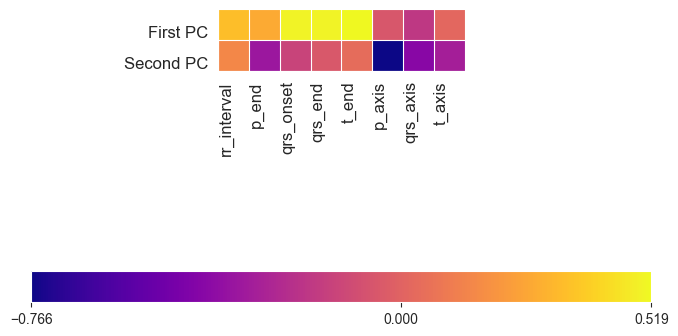

In [23]:
fig = plt.figure(figsize=(8, 4))
plt.imshow(pca.components_, interpolation = 'none', cmap = 'plasma')
feature_names = list(data_pca.columns)
plt.gca().set_xticks(np.arange(-.5, len(feature_names)-1));
plt.gca().set_yticks(np.arange(0.5, 2));
plt.gca().set_xticklabels(feature_names, rotation=90, ha='left',fontsize=12);
plt.gca().set_yticklabels(['First PC', 'Second PC'], va='bottom',fontsize=12);
plt.colorbar(orientation='horizontal', ticks=[pca.components_.min(), 0,
                                              pca.components_.max()],pad=0.65);

Text(0, 0.5, 'Second Principal Component')

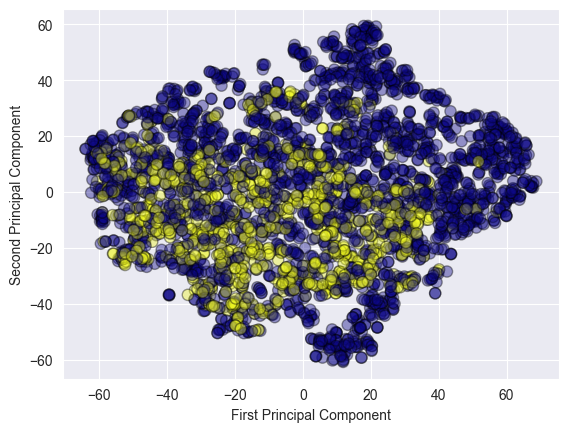

In [24]:
# t-SNE stohastic neighbor embedings

from sklearn.manifold import TSNE
tsne = TSNE(random_state = 0)
scaled_data_tsne = tsne.fit_transform(scaled_data)
plt.scatter(scaled_data_tsne[:,0], scaled_data_tsne[:,1], c=table_data['Healthy_Status'], cmap='plasma', alpha=0.4, edgecolors='black', s=65);
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

In [10]:
from sklearn import manifold
from time import time

Time code evaluation for perplexity=1 in 7.5 sec
Time code evaluation for perplexity=5 in 7.4 sec
Time code evaluation for perplexity=10 in 7.9 sec
Time code evaluation for perplexity=15 in 8.5 sec
Time code evaluation for perplexity=20 in 9.2 sec
Time code evaluation for perplexity=30 in 9.6 sec
Time code evaluation for perplexity=40 in 10 sec
Time code evaluation for perplexity=50 in 11 sec
Time code evaluation for perplexity=100 in 16 sec


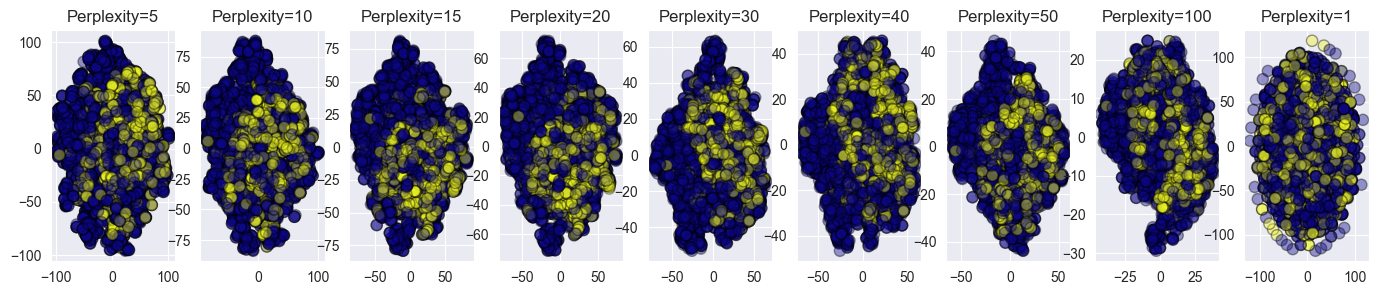

In [27]:
n_components = 2
perplexities = [1, 5, 10, 15, 20, 30, 40, 50, 100]
# perplexities = [5, 10]

(fig, subplots) = plt.subplots(1, len(perplexities), figsize=(17, 3))

for i, perplexity in enumerate(perplexities):
    ax = subplots[i-1]

    t0 = time()
    tsne = manifold.TSNE(
        n_components=n_components,
        init="random",
        random_state=0,
        perplexity=perplexity,
        # max_iter=300,
        )

    scaled_data_tsne = tsne.fit_transform(scaled_data)
    t1 = time()

    print("Time code evaluation for perplexity=%d in %.2g sec" % (perplexity, t1 - t0))

    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(scaled_data_tsne[:,0], scaled_data_tsne[:,1],
               c=table_data['Healthy_Status'],
               cmap='plasma',
               alpha=0.4,
               edgecolors='black',
               s=65
               );
    ax.axis("tight")

Text(0, 0.5, 'Second Independed Component')

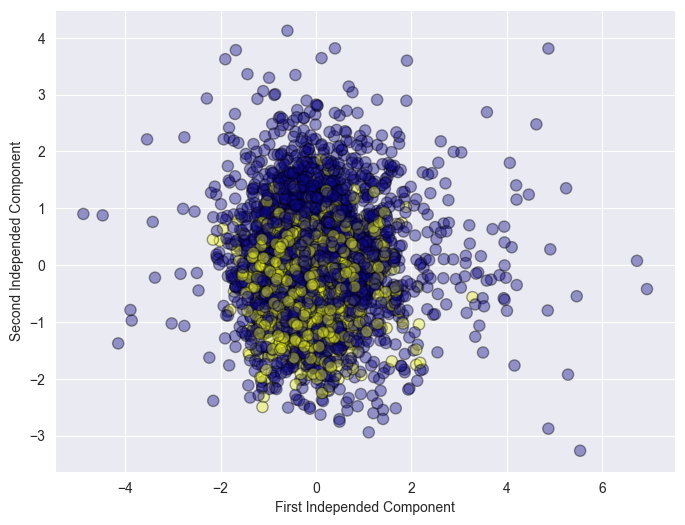

In [28]:
# ICA independed component analysis

#Creating input data numpy array
#X = scaled_data.values
from sklearn.decomposition import FastICA
######################################################################
# Creating ICA object
ICA = FastICA(n_components=2)
scaled_data_ica = ICA.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(scaled_data_ica[:,0],
            scaled_data_ica[:,1],
            c=table_data['Healthy_Status'],
            cmap='plasma',
            alpha=0.4,
            edgecolors='black',
            s=65
            );
plt.xlabel('First Independed Component')
plt.ylabel('Second Independed Component')

In [11]:
# ML методы
# ML: GussianClassifier + описание классов и матрица ошибок
from sklearn import metrics
from sklearn.metrics import classification_report,confusion_matrix
table_data.columns


Index(['rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis',
       'qrs_axis', 't_axis', 'Healthy_Status'],
      dtype='object')

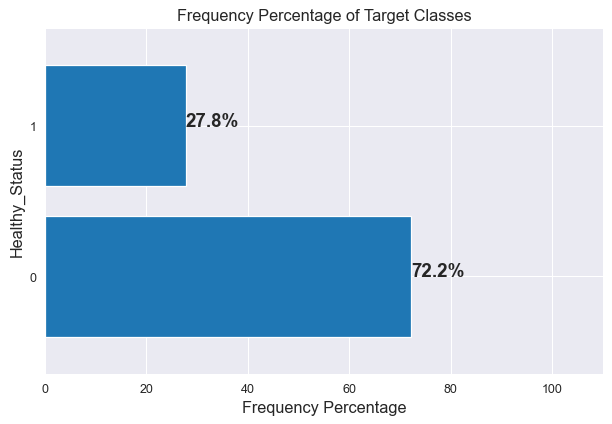

In [12]:
# set the classification index of table #
clf_index = 8

plt.figure(figsize=(35,20),dpi=90)
# Plot frequency percentages barplot
table_data[table_data.columns[clf_index]].value_counts(normalize=True).mul(100).plot(kind='barh', width=0.8, figsize=(8,5))


# Add frequency percentages to the plot
labels = table_data[table_data.columns[clf_index]].value_counts(normalize=True).mul(100).round(1)
for i in labels.index:
    plt.text(labels[i], i, str(labels[i])+ '%', fontsize=15, weight='bold')

plt.xlim([0, 110])
plt.xlabel('Frequency Percentage', fontsize=13)
plt.ylabel(table_data.columns[clf_index], fontsize=13)
plt.title('Frequency Percentage of Target Classes', fontsize=13)
plt.show()

In [13]:
# classification variable
y1 = table_data.iloc[:, clf_index]
# input variable
X1 = table_data.drop(table_data.columns[[clf_index]], axis=1).iloc[:,:]

y1 = pd.Series(LabelEncoder().fit_transform(y1))
X1_train, X1_test, y1_train, y1_test = train_test_split(X1.values,
                                                        y1.values,
                                                        test_size=0.3,
                                                        random_state=0,
                                                        stratify=y1.values)

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X1.values,
                                                 y1.values,
                                                 test_size=0.3,
                                                 random_state=41,
                                                 stratify=y1.values)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2413, 8)
y_train shape: (2413,)
X_test shape: (1035, 8)
y_test shape: (1035,)


In [15]:
GussianClassifier = GaussianNB()
GussianClassifier.fit(X1_train,y1_train)
y_pred=GussianClassifier.predict(X_test)
print("===================================> Result <===================================")
print("Accuracy                     = " ,metrics.accuracy_score(y_test,y_pred))
print("F1 Score                     = " ,metrics.f1_score(y_test,y_pred))

===================================> Result <===================================
Accuracy                     =  0.7613526570048309
F1 Score                     =  0.6394160583941606


              precision    recall  f1-score   support

        True       0.89      0.76      0.82       747
       False       0.55      0.76      0.64       288

    accuracy                           0.76      1035
   macro avg       0.72      0.76      0.73      1035
weighted avg       0.80      0.76      0.77      1035



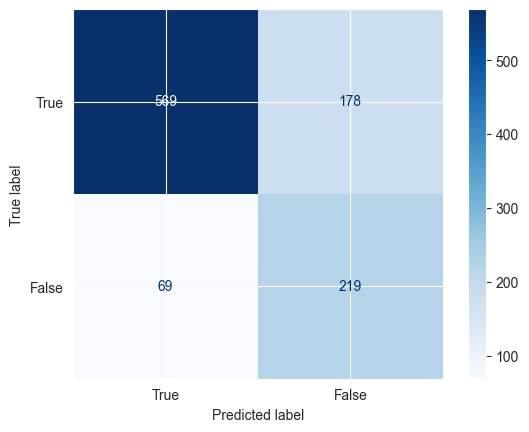

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
target_names = ['True', 'False']
labels_names = [0,1]
print(classification_report(y_test, y_pred,labels=labels_names, target_names=target_names))
#cm = confusion_matrix(y_test, y_pred,labels=labels_names,normalize='true')
cm = confusion_matrix(y_test, y_pred,labels=labels_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=target_names)
disp = disp.plot(cmap=plt.cm.Blues,values_format='g')
plt.show()

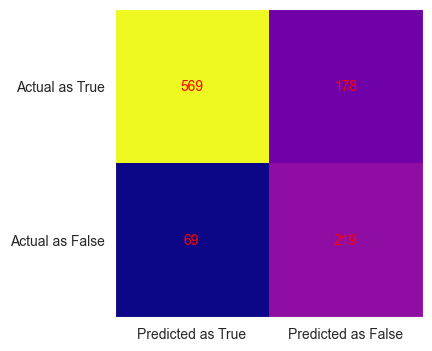

In [35]:
cm = confusion_matrix(y_test,GussianClassifier.predict(X_test))

fig , ax  = plt.subplots(figsize=(4,4))
ax.imshow(cm, cmap = 'plasma')
ax.grid(False)
ax.xaxis.set(ticks=(0,1),ticklabels=("Predicted as True","Predicted as False"))
ax.yaxis.set(ticks=(0,1),ticklabels=("Actual as True","Actual as False"))
ax.set_ylim(1.5,-0.5)
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",color = "red")

In [6]:
# AutoML examples

# Убираем из датасета лишние столбцы
# Формируем датасет для AutoML методов

autoML_df = full_df_filtered[['rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status']].copy()
# autoML_df = data.copy()

import autogluon
# Импортируем необходимые библиотеки
from autogluon.tabular import TabularPredictor
autoML_df.head()


,rr_interval,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,659,128,170,258,518,81,77,79,0
1,722,124,162,246,504,77,75,70,0
2,600,130,162,244,474,79,72,77,1
3,659,146,180,254,538,79,66,69,1
6,952,146,198,282,598,24,80,20,1


In [7]:
# Разбиение на обучающую и тестовую выборки
random_seed = 17

# set the classification index of table
clf_index = 8
target = 'Healthy_Status'

auto_X = autoML_df.iloc[:, :clf_index]
auto_Y = autoML_df.iloc[:, [clf_index]]
print(auto_X)
# print(auto_Y)

auto_X_train, auto_X_test, auto_Y_train, auto_Y_test = train_test_split(
                                                        auto_X, auto_Y,
                                                        train_size=0.85,
                                                        random_state=random_seed,
                                                        stratify=auto_Y
                                                        )

# Создаем обучающий датафрейм
auto_train_df = auto_X_train.copy()
auto_test_df = auto_X_test.copy()
auto_train_df['Healthy_Status'] = auto_Y_train
auto_test_df['Healthy_Status'] = auto_Y_test


      rr_interval  p_end  qrs_onset  qrs_end  t_end  p_axis  qrs_axis  t_axis
0             659    128        170      258    518      81        77      79
1             722    124        162      246    504      77        75      70
2             600    130        162      244    474      79        72      77
3             659    146        180      254    538      79        66      69
6             952    146        198      282    598      24        80      20
...           ...    ...        ...      ...    ...     ...       ...     ...
4967          909    154        210      294    606      37        43       7
4969          714    158        224      314    608      47         5      45
4970          731    150        208      302    612      54         8      47
4971          681    146        204      296    596      59        11      53
4989          535    148        218      330    548       1        -1      23

[3448 rows x 8 columns]


In [8]:
# Создаем и обучаем модель
predictor = TabularPredictor(label='Healthy_Status', eval_metric='accuracy').fit(train_data=auto_train_df)

# Предсказание на тестовой выборке
y_pred = predictor.predict(auto_X_test)


No path specified. Models will be saved in: "AutogluonModels/ag-20250415_195642"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.9.13
Operating System:   Darwin
Platform Machine:   x86_64
Platform Version:   Darwin Kernel Version 22.6.0: Thu Dec  5 23:45:11 PST 2024; root:xnu-8796.141.3.709.7~4/RELEASE_X86_64
CPU Count:          8
Memory Avail:       5.70 GB / 16.00 GB (35.6%)
Disk Space Avail:   221.31 GB / 465.63 GB (47.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accurac

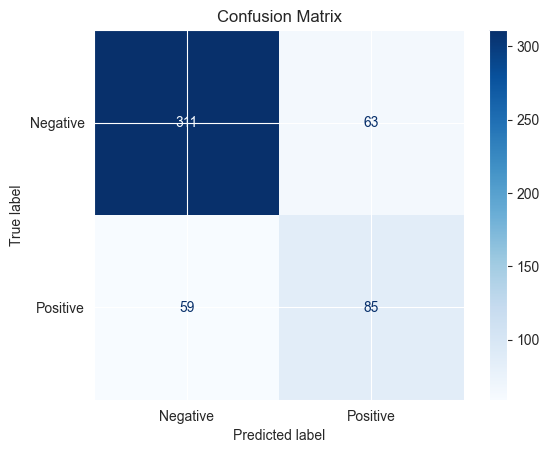

In [14]:

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(auto_Y_test, y_pred)

# 类别标签（假设是二分类）
class_names = ["Negative", "Positive"]

# 绘制混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format="d")  # "d" 表示整数格式

# 添加标题
plt.title("Confusion Matrix")
plt.show()



In [44]:
predictor.leaderboard(auto_test_df)

/Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetFastAI,0.799228,0.784431,accuracy,0.022402,0.022731,2.594856,0.022402,0.022731,2.594856,1,True,8
1,RandomForestGini,0.777992,0.768463,accuracy,0.112978,0.057876,1.073334,0.112978,0.057876,1.073334,1,True,3
2,ExtraTreesGini,0.774131,0.742515,accuracy,0.127325,0.062972,0.885349,0.127325,0.062972,0.885349,1,True,6
3,RandomForestEntr,0.772201,0.776447,accuracy,0.096026,0.056224,0.955695,0.096026,0.056224,0.955695,1,True,4
4,ExtraTreesEntr,0.768340,0.760479,accuracy,0.112104,0.046599,0.863054,0.112104,0.046599,0.863054,1,True,7
5,CatBoost,0.764479,0.800399,accuracy,0.007190,0.002225,0.973990,0.007190,0.002225,0.973990,1,True,5
6,WeightedEnsemble_L2,0.764479,0.800399,accuracy,0.008741,0.003609,1.031243,0.001551,0.001384,0.057253,2,True,9
7,KNeighborsDist,0.743243,0.750499,accuracy,0.019353,0.014329,0.012073,0.019353,0.014329,0.012073,1,True,2
8,KNeighborsUnif,0.739382,0.746507,accuracy,0.021288,0.047062,3.245415,0.021288,0.047062,3.245415,1,True,1


## Target variable analysis

### Label Insights

 - Mild minority class imbalance detected - imbalance ratio is `38.60%`. Recommendations:
   - downsample majority class `0` to improve the balance
   - upweight downsampled class so that `sample_weight = original_weight x downsampling_factor`.[TabularPredictor](https://auto.gluon.ai/stable/api/autogluon.predictor.html#module-0) supports this via `sample_weight` parameter

,count,mean,std,min,25%,50%,75%,max,dtypes,unique,missing_count,missing_ratio,raw_type,special_types
Healthy_Status,2930,0.278498,0.448336,0.0,0.0,0.0,1.0,1.0,int64,2,,,int,


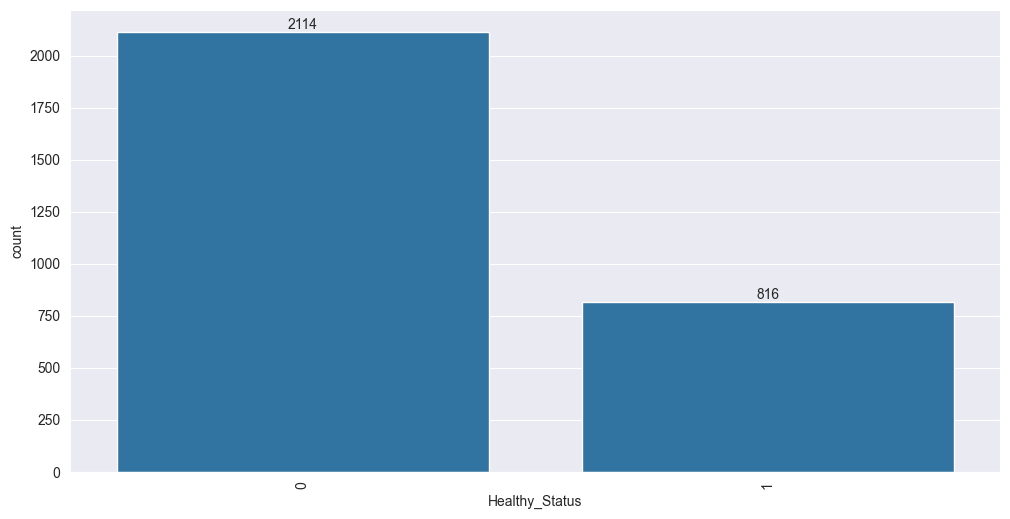

### Target variable correlations
 - ⚠️ no fields with absolute correlation greater than `0.5` found for target variable `Healthy_Status`.

In [45]:
import autogluon.eda.auto as auto
auto.target_analysis(train_data=auto_train_df, label=target)



In [46]:
print(auto_train_df)



      rr_interval  p_end  qrs_onset  qrs_end  t_end  p_axis  qrs_axis  t_axis  \
2809          821    148        230      316    638      52         3     146   
4401          625    146        156      286    540       2       -11     -15   
3473          869    132        210      296    618      63        10      72   
1578         1090    138        194      272    666      37        83      85   
2612          923    148        228      316    646      62        14      24   
...           ...    ...        ...      ...    ...     ...       ...     ...   
2280         1071    118        202      288    648      28        37      64   
206           759    154        222      318    656      25        15     151   
2533          576    146        204      286    554      39       -16     -26   
4837          750    160        186      264    554      68        32      42   
1006          952    176        220      312    626      36        -3       9   

      Healthy_Status  
2809

**`train_data` dataset summary**

,count,mean,std,min,25%,50%,75%,max,dtypes,unique,missing_count,missing_ratio,raw_type,variable_type,special_types
Healthy_Status,2930,0.278498,0.448336,0.0,0.0,0.0,1.0,1.0,int64,2,,,int,category,
p_axis,2930,46.058362,28.895894,-180.0,34.0,52.0,64.0,179.0,int64,193,,,int,numeric,
p_end,2930,148.263481,18.254195,48.0,138.0,150.0,160.0,204.0,int64,63,,,int,numeric,
qrs_axis,2930,16.315700,39.293083,-172.0,-9.0,16.0,46.0,177.0,int64,216,,,int,numeric,
qrs_end,2930,296.683276,38.492079,160.0,272.0,292.0,316.0,480.0,int64,130,,,int,numeric,
qrs_onset,2930,202.108532,30.430672,80.0,182.0,200.0,220.0,346.0,int64,103,,,int,numeric,
rr_interval,2930,826.341980,184.825330,416.0,697.0,821.0,952.0,1666.0,int64,103,,,int,numeric,
t_axis,2930,43.184300,49.745616,-180.0,18.0,44.0,67.0,179.0,int64,294,,,int,numeric,
t_end,2930,597.755631,62.103717,392.0,556.0,598.0,636.0,826.0,int64,185,,,int,numeric,


**`test_data` dataset summary**

,count,mean,std,min,25%,50%,75%,max,dtypes,unique,missing_count,missing_ratio,raw_type,variable_type,special_types
Healthy_Status,518,0.277992,0.448443,0.0,0.0,0.0,1.0,1.0,int64,2,,,int,category,
p_axis,518,44.642857,30.874643,-142.0,33.0,50.0,63.0,171.0,int64,117,,,int,numeric,
p_end,518,148.027027,18.472606,82.0,138.0,150.0,158.0,200.0,int64,51,,,int,numeric,
qrs_axis,518,16.332046,38.937357,-160.0,-9.0,15.0,45.0,154.0,int64,154,,,int,numeric,
qrs_end,518,298.397683,37.390978,220.0,272.0,294.0,315.5,470.0,int64,84,,,int,numeric,
qrs_onset,518,202.594595,29.038255,116.0,182.0,202.0,218.0,338.0,int64,71,,,int,numeric,
rr_interval,518,834.289575,199.787211,419.0,689.0,833.0,967.0,1578.0,int64,85,,,int,numeric,
t_axis,518,43.513514,50.102398,-179.0,19.0,44.0,68.0,179.0,int64,170,,,int,numeric,
t_end,518,600.123552,62.797210,414.0,558.0,599.0,640.0,794.0,int64,136,,,int,numeric,


### Feature Distance

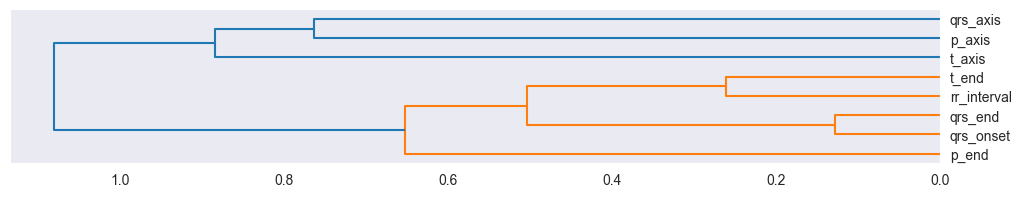

In [47]:
auto.dataset_overview(train_data=auto_train_df,
                      test_data=auto_test_df,
                      label="Healthy_Status",
                      )


In [51]:
predictor.quick_fit(auto_train_df, target_col=target, show_feature_importance_barplots=True)

AttributeError: module 'autogluon.eda.auto' has no attribute 'predictor'

In [15]:
import h2o
from h2o.frame import H2OFrame
from h2o.automl import H2OAutoML
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score

In [16]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,2 hours 4 mins
H2O_cluster_timezone:,Asia/Shanghai
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,19 days
H2O_cluster_name:,H2O_from_python_teng_81ngjs
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.933 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [17]:
# Переводим датафрейм в формат H2OFrame
h2o_df = H2OFrame(autoML_df)

# Разбиение на обучающую и тестовую выборки
random_seed = 17
train, test = h2o_df.split_frame(ratios=[0.85], seed=random_seed)

# Определяем целевую переменную и предикторы
y="Healthy_Status"
x = list(h2o_df.columns)
x.remove(y)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [18]:
# Создаем и обучаем модель H2O AutoML
automl = H2OAutoML(max_runtime_secs=60, seed=random_seed, verbosity="info")
#automl= H2OAutoML(max_models = 10, seed = 10, exclude_algos = ["StackedEnsemble", "DeepLearning"], verbosity="info", nfolds=0)


automl.train(x=x, y=y, training_frame=train)

# Оценка модели на тестовом наборе
performance = automl.leader.model_performance(test_data=test)
print(performance)

AutoML progress: |
04:08:55.360: Project: AutoML_2_20250416_40855
04:08:55.360: 5-fold cross-validation will be used.
04:08:55.360: Setting stopping tolerance adaptively based on the training frame: 0.018464772811525407
04:08:55.361: Build control seed: 17
04:08:55.361: training frame: Frame key: AutoML_2_20250416_40855_training_py_2_sid_9a67    cols: 9    rows: 2933  chunks: 1    size: 44976  checksum: -31847221819231
04:08:55.361: validation frame: NULL
04:08:55.361: leaderboard frame: NULL
04:08:55.361: blending frame: NULL
04:08:55.361: response column: Healthy_Status
04:08:55.361: fold column: null
04:08:55.361: weights column: null
04:08:55.362: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (6g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {GBM : [def_5 (1g, 10w), def_2 (2g, 10w), def_3 (2g, 10w), def_4 (2g, 10w), def_1 (3g, 10w), grid_1 (4g, 60w), lr_annealing (6g, 10w)]}, {Dee

In [19]:
lb = automl.leaderboard
lb.head()

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
StackedEnsemble_BestOfFamily_4_AutoML_2_20250416_40855,0.357159,0.127563,0.264493,0.250552,0.127563
StackedEnsemble_AllModels_4_AutoML_2_20250416_40855,0.357587,0.127869,0.266543,0.251222,0.127869
StackedEnsemble_AllModels_2_AutoML_2_20250416_40855,0.357648,0.127912,0.265547,0.251102,0.127912
StackedEnsemble_AllModels_1_AutoML_2_20250416_40855,0.357689,0.127942,0.266775,0.251248,0.127942
StackedEnsemble_BestOfFamily_2_AutoML_2_20250416_40855,0.357701,0.12795,0.266425,0.251115,0.12795
StackedEnsemble_BestOfFamily_3_AutoML_2_20250416_40855,0.357832,0.128044,0.265273,0.251028,0.128044
StackedEnsemble_AllModels_3_AutoML_2_20250416_40855,0.359029,0.128902,0.267567,0.252165,0.128902
GBM_3_AutoML_2_20250416_40855,0.359244,0.129056,0.272043,0.252285,0.129056
GBM_grid_1_AutoML_2_20250416_40855_model_10,0.359718,0.129397,0.274812,0.252994,0.129397
GBM_grid_1_AutoML_2_20250416_40855_model_4,0.361006,0.130325,0.282018,0.254042,0.130325


In [26]:
model_ids = list(automl.leaderboard['model_id'].as_data_frame(use_multi_thread=True).iloc[:,0])
model_ids

/Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


['StackedEnsemble_BestOfFamily_4_AutoML_2_20250416_40855',
 'StackedEnsemble_AllModels_4_AutoML_2_20250416_40855',
 'StackedEnsemble_AllModels_2_AutoML_2_20250416_40855',
 'StackedEnsemble_AllModels_1_AutoML_2_20250416_40855',
 'StackedEnsemble_BestOfFamily_2_AutoML_2_20250416_40855',
 'StackedEnsemble_BestOfFamily_3_AutoML_2_20250416_40855',
 'StackedEnsemble_AllModels_3_AutoML_2_20250416_40855',
 'GBM_3_AutoML_2_20250416_40855',
 'GBM_grid_1_AutoML_2_20250416_40855_model_10',
 'GBM_grid_1_AutoML_2_20250416_40855_model_4',
 'GBM_grid_1_AutoML_2_20250416_40855_model_8',
 'DRF_1_AutoML_2_20250416_40855',
 'GBM_4_AutoML_2_20250416_40855',
 'GBM_grid_1_AutoML_2_20250416_40855_model_14',
 'GBM_2_AutoML_2_20250416_40855',
 'GBM_grid_1_AutoML_2_20250416_40855_model_11',
 'GBM_5_AutoML_2_20250416_40855',
 'XRT_1_AutoML_2_20250416_40855',
 'GBM_grid_1_AutoML_2_20250416_40855_model_13',
 'GBM_grid_1_AutoML_2_20250416_40855_model_16',
 'GBM_grid_1_AutoML_2_20250416_40855_model_29',
 'StackedEnse

In [21]:
out = h2o.get_model([mid for mid in model_ids if "XGBoost" in mid][0])
out.convert_H2OXGBoostParams_2_XGBoostParams()

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <FBD6AEF9-AFAB-39D7-B881-755157DA0497> /Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib

In [22]:
automl.leader.model_performance(test)

ModelMetricsRegressionGLM: stackedensemble
** Reported on test data. **

MSE: 0.12166192281397815
RMSE: 0.3488006921065068
MAE: 0.251030057593542
RMSLE: 0.2493051026031863
Mean Residual Deviance: 0.12166192281397815
R^2: 0.3380967491623107
Null degrees of freedom: 514
Residual degrees of freedom: 508
Null deviance: 95.56748634029051
Residual deviance: 62.65589024919875
AIC: 392.65444842086873

In [29]:
test_predict = automl.predict(test)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


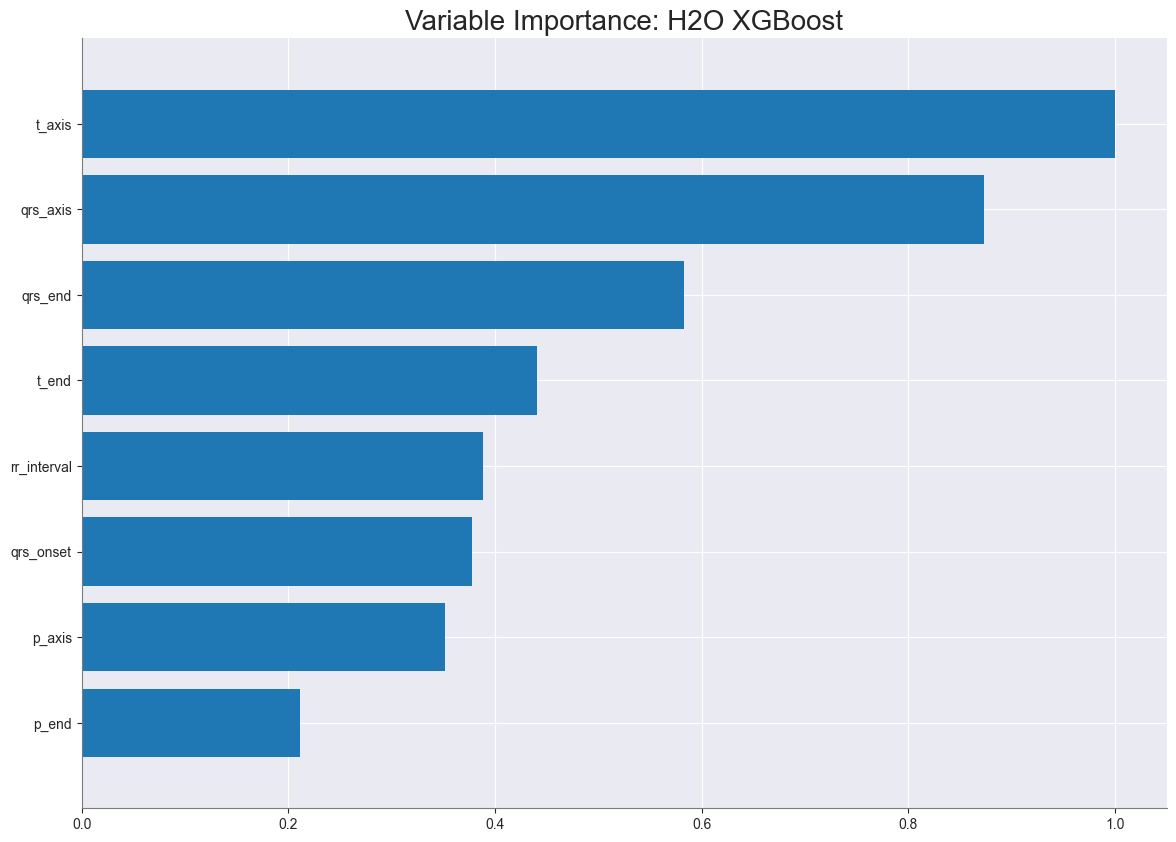

<Figure size 640x480 with 0 Axes>

In [24]:
out.varimp_plot()

In [30]:
# H2OFrame
test_preds = test_predict.as_data_frame(use_multi_thread=True)
test_preds = test_preds['predict']

/Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [31]:
test_Y = h2o.as_list(test['Healthy_Status'])
test_Y = test_Y['Healthy_Status']

/Users/teng/PycharmProjects/ML/.venv/lib/python3.9/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [32]:
# Вычисляем F1-меру с помощью confusion matrix

# Порог отсечения - 0.5
for i in range(len(test_preds)):
  if test_preds[i] > 0.5:
    test_preds[i] = 1
  else:
    test_preds[i] = 0


cm = confusion_matrix(test_Y, test_preds)
TN, FP, FN, TP = cm.ravel()
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
Accuracy = (TP + TN) / (TP + TN + FN + FP)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

roc_auc = roc_auc_score(test_Y, test_preds)

print("Confusion matrix:", cm)
print("F1-Score: ", "{:.2f}".format(f1_score))
print("Accuracy:", "{:.2f}".format(Accuracy))
print("Recall: ", r"{:.2f}".format(recall))
print("Precision: ","{:.2f}".format(precision))

Confusion matrix: [[339  51]
 [ 39  86]]
F1-Score:  0.66
Accuracy: 0.83
Recall:  0.69
Precision:  0.63


In [ ]:
# Завершение работы H2O
h2o.shutdown()

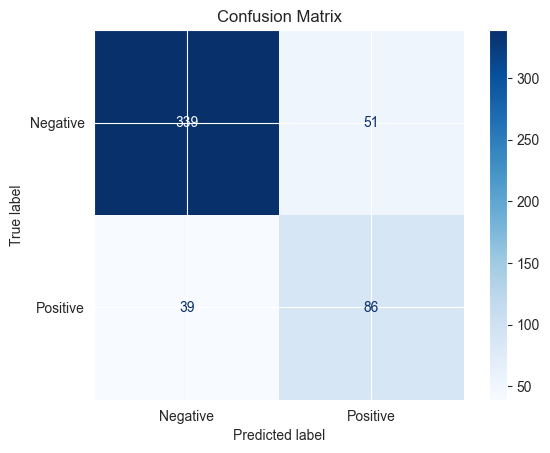

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 你的混淆矩阵数据
cm = cm

# 类别标签（假设是二分类）
class_names = ["Negative", "Positive"]

# 绘制混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format="d")  # "d" 表示整数格式

# 添加标题
plt.title("Confusion Matrix")
plt.show()